count    16521.000000
mean        31.201184
std         33.315455
min          0.000000
25%          4.300000
50%         15.920000
75%         54.500000
max        148.350000
Name: Tc, dtype: float64
No missing values found.


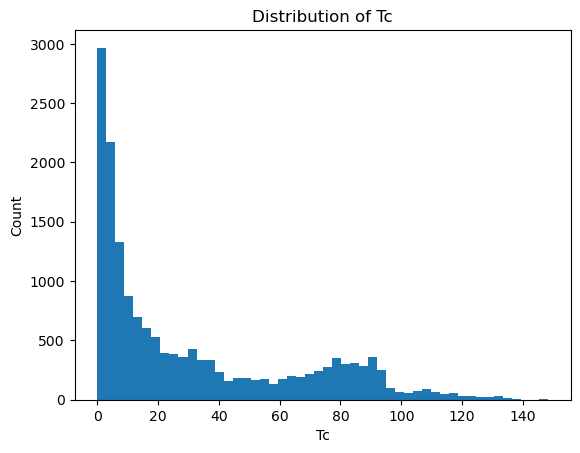

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("archive/featurized.csv")

print(df["Tc"].describe())

missing = df.isnull().sum()

if missing[missing > 0].any():
    print("Missing values:")
    print(missing[missing > 0])
else:    
    print("No missing values found.")

plt.hist(df["Tc"], bins=50)
plt.xlabel("Tc")
plt.ylabel("Count")
plt.title("Distribution of Tc")
plt.show()

Tc                                      1.000000
MagpieData avg_dev GSvolume_pa          0.674934
max ionic char                          0.666474
MagpieData range Electronegativity      0.658077
avg ionic char                          0.645520
MagpieData range GSvolume_pa            0.640880
0-norm                                  0.628522
MagpieData avg_dev Electronegativity    0.626278
MagpieData range CovalentRadius         0.619882
MagpieData maximum Electronegativity    0.619555
MagpieData maximum GSvolume_pa          0.614040
MagpieData avg_dev SpaceGroupNumber     0.588289
MagpieData range SpaceGroupNumber       0.582339
MagpieData avg_dev CovalentRadius       0.553096
MagpieData range MendeleevNumber        0.546263
MagpieData range Row                    0.543313
MagpieData avg_dev NdValence            0.540574
MagpieData range Column                 0.529751
MagpieData avg_dev MendeleevNumber      0.524458
MagpieData range NpValence              0.522163
Name: Tc, dtype: flo

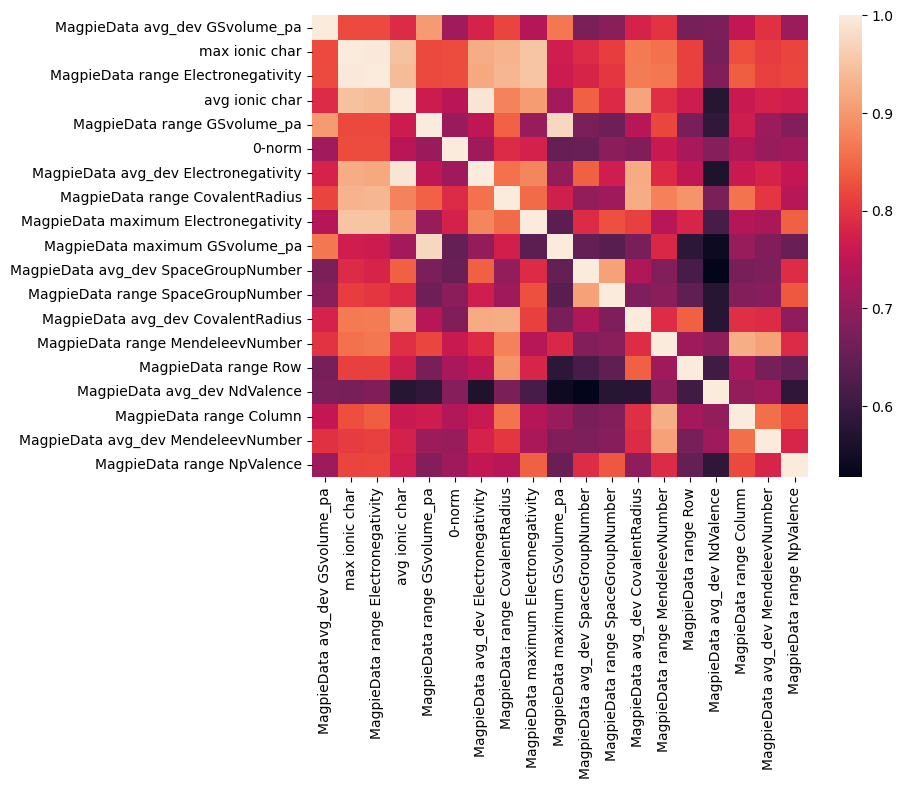

In [6]:
corr = df.corr(numeric_only=True)
tc_corr = corr["Tc"].sort_values(ascending=False)
print(tc_corr.head(20))

import seaborn as sns

top_features = tc_corr.index[1:20]
plt.figure(figsize=(8,6))
sns.heatmap(df[top_features].corr())
plt.show()

MagpieData avg_dev GSvolume_pa          0.540167
MagpieData mean NUnfilled               0.110140
MagpieData range CovalentRadius         0.026919
MagpieData mean NsUnfilled              0.016308
MagpieData range Column                 0.015348
MagpieData avg_dev NsUnfilled           0.014067
transition metal fraction               0.012364
MagpieData avg_dev MendeleevNumber      0.009902
MagpieData avg_dev Column               0.008816
MagpieData minimum MendeleevNumber      0.008347
MagpieData mean AtomicWeight            0.007558
MagpieData avg_dev MeltingT             0.007407
2-norm                                  0.007306
MagpieData avg_dev CovalentRadius       0.007213
MagpieData avg_dev NUnfilled            0.007079
MagpieData avg_dev Electronegativity    0.006775
MagpieData avg_dev Number               0.006408
MagpieData mean MeltingT                0.006030
max ionic char                          0.005944
MagpieData avg_dev SpaceGroupNumber     0.005913
dtype: float64


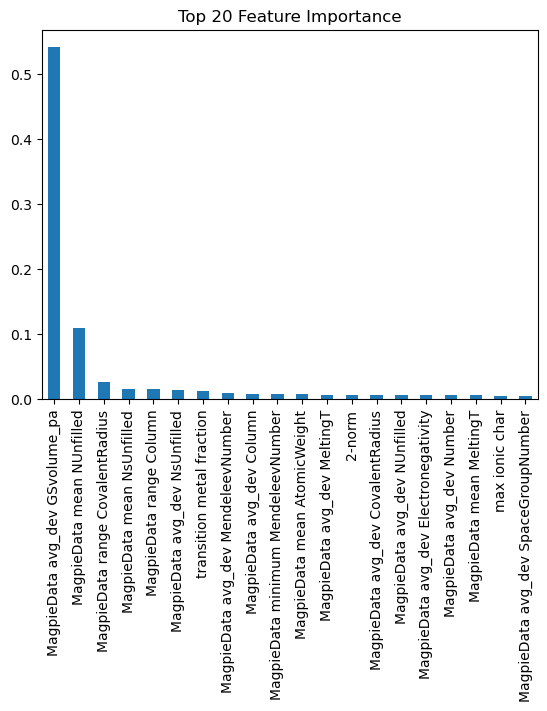

In [8]:
from sklearn.ensemble import RandomForestRegressor

df = df.copy()
X = df.drop(columns=["Tc","formula","composition","category"])
y = df["Tc"]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance.head(20))

importance.head(20).plot.bar()
plt.title("Top 20 Feature Importance")
plt.show()

In [10]:

import numpy as np
df = df.copy()
X = df.drop(columns=["Tc","formula","composition","category"])
y = df["Tc"]
corr_matrix = X.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

X_reduced = X.drop(columns=to_drop)

print("Original features:", X.shape[1])
print("Reduced features:", X_reduced.shape[1])

Original features: 146
Reduced features: 114


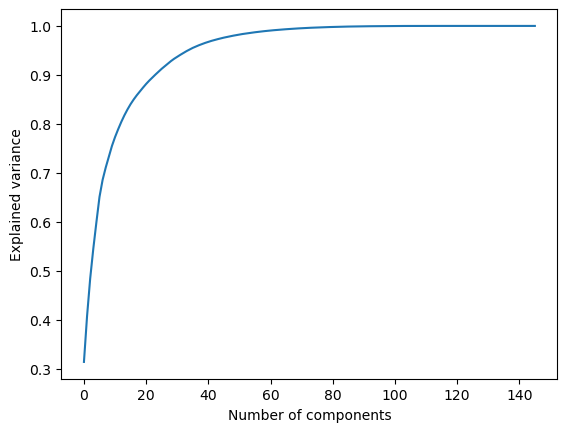

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = df.copy()
X = df.drop(columns=["Tc","formula","composition","category"])
y = df["Tc"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of components")
plt.ylabel("Explained variance")
plt.show()

is_sc
1    16463
0       58
Name: count, dtype: int64


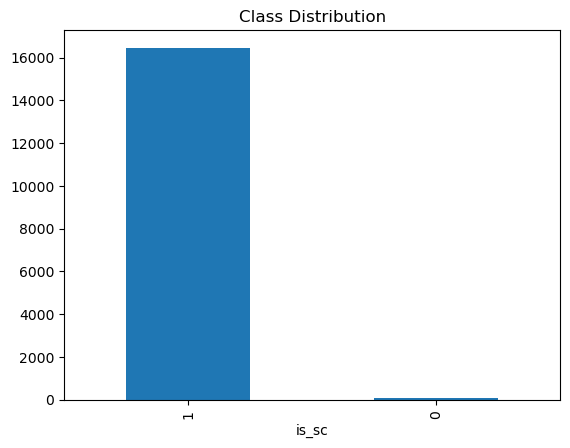

In [13]:
df = df.copy()
df["is_sc"] = (df["Tc"] > 0).astype(int)

print(df["is_sc"].value_counts())

df["is_sc"].value_counts().plot.bar()
plt.title("Class Distribution")
plt.show()

---

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df = df.copy()
X = df.drop(columns=["Tc","formula","composition","category"])
y = df["Tc"]
X_scaled = scaler.fit_transform(X)

rf = RandomForestRegressor()

scores = cross_val_score(
    rf,
    X_scaled,
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)

print(scores.mean())

-283.04092711376904


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [18]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

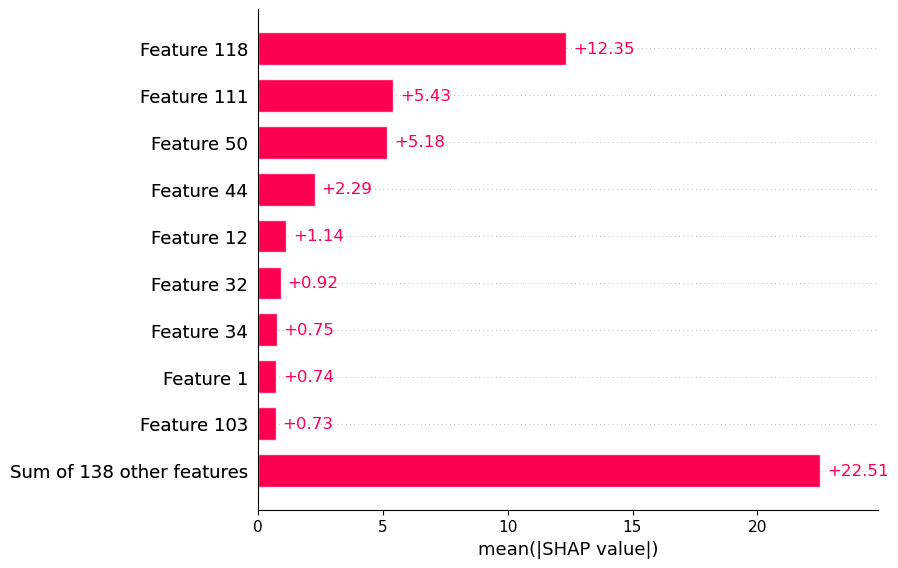

In [19]:
shap.plots.bar(shap_values)

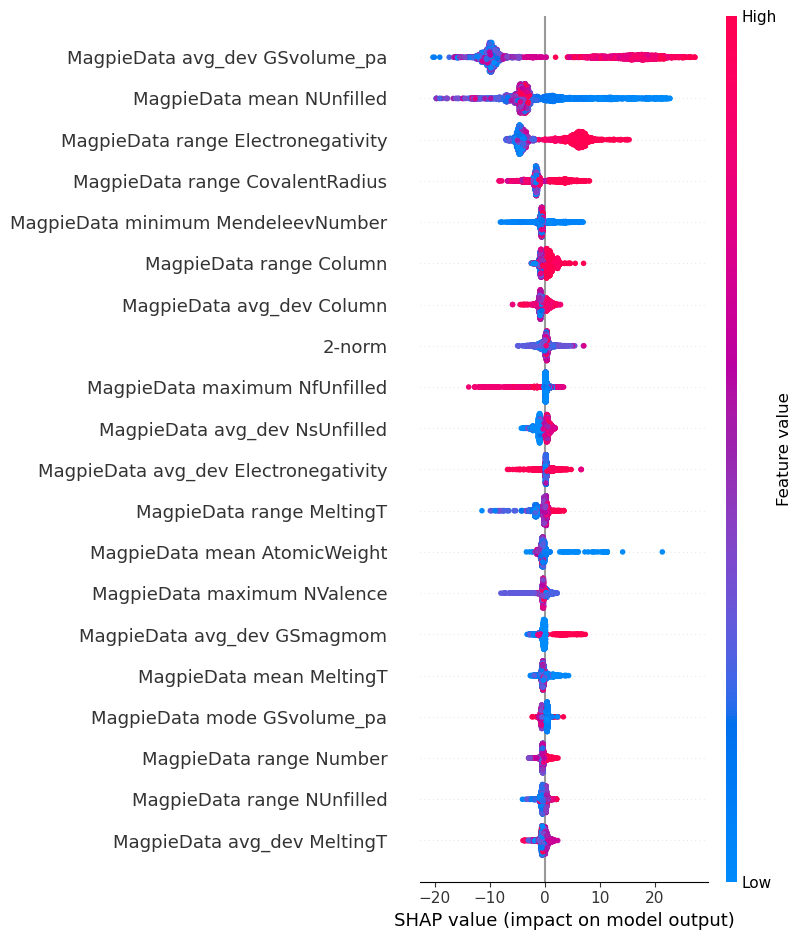

In [20]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

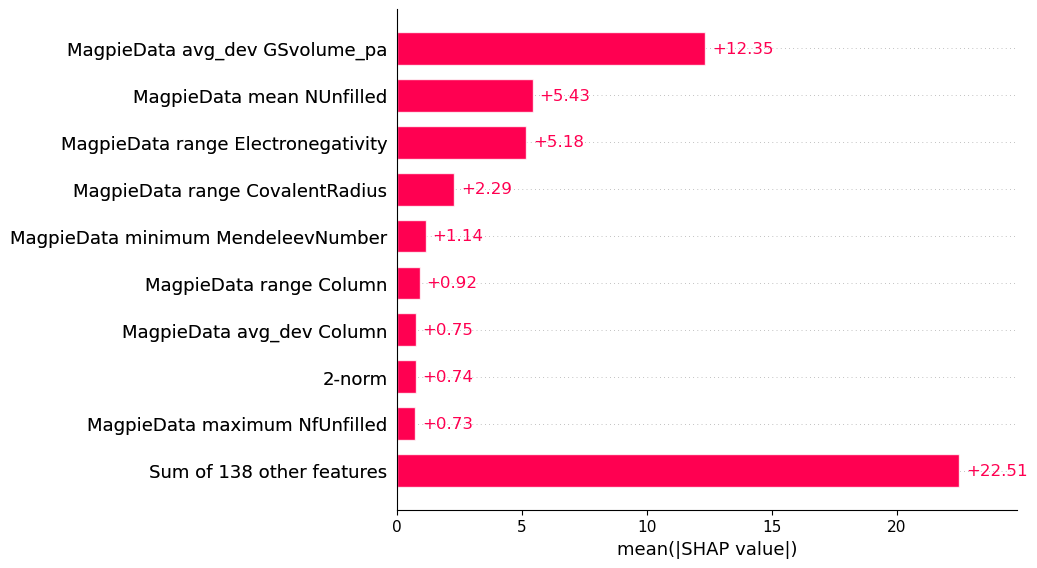

In [21]:
shap_values.feature_names = list(X.columns)
shap.plots.bar(shap_values)

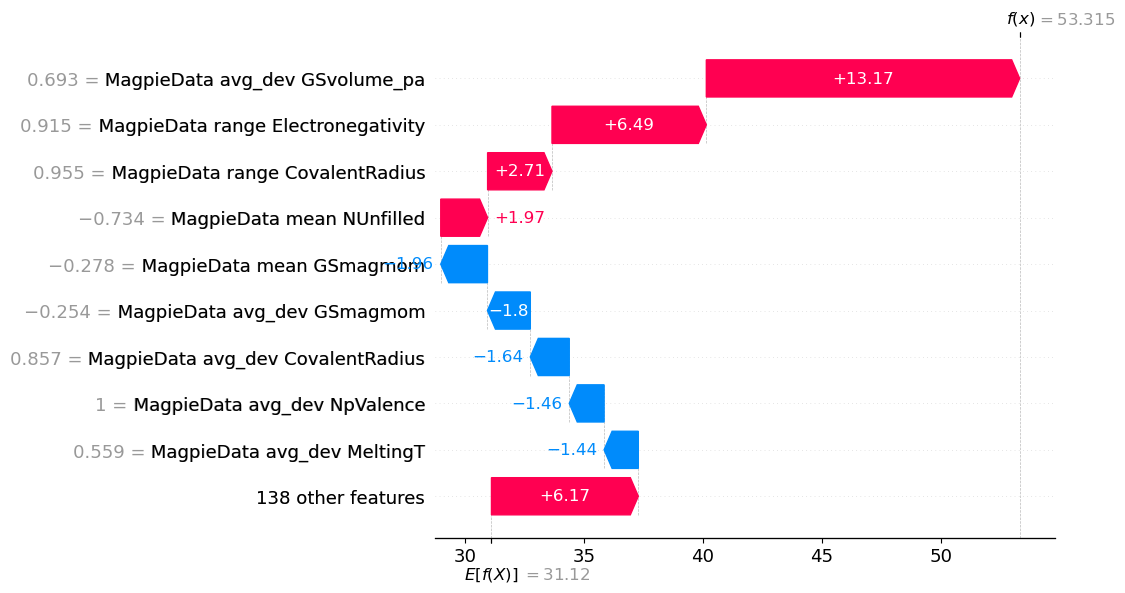

In [32]:
shap.plots.waterfall(shap_values[0])

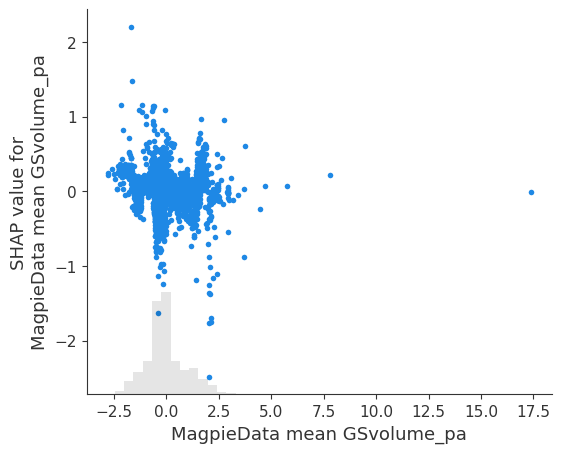

In [28]:
feature_idx = shap_values.feature_names.index("MagpieData mean GSvolume_pa")
shap.plots.scatter(shap_values[:, feature_idx])

### Giải thích chi tiết đặc trưng `MagpieData avg_dev GSvolume_pa` trong mô hình dự đoán Nhiệt độ tới hạn ($T_c$)

Dựa trên việc sử dụng bộ dữ liệu **SuperCon** (dự đoán nhiệt độ tới hạn $T_c$ của vật liệu siêu dẫn) và kết quả phân tích SHAP, đặc trưng `MagpieData avg_dev GSvolume_pa` đóng vai trò quan trọng nhất. Dưới đây là giải nghĩa chi tiết về mặt dữ liệu và vật lý của biến này:

#### 1. Ý nghĩa tên gọi của biến
* **MagpieData:** Là tên của bộ công cụ trích xuất đặc trưng vật liệu dựa trên thành phần hóa học.
* **avg_dev (Average Deviation - Độ lệch trung bình):** Thể hiện mức độ phân tán, chênh lệch của một thuộc tính so với giá trị trung bình của toàn bộ hợp chất.
* **GSvolume_pa (Ground State volume per atom):** Thể tích không gian mà một nguyên tử chiếm chỗ khi nó ở trạng thái cơ bản (trạng thái năng lượng thấp nhất).

👉 **Kết luận:** Biến này đo lường **sự chênh lệch về mặt kích thước (thể tích) giữa các nguyên tử** cấu thành nên vật liệu. 
* Nếu vật liệu gồm các nguyên tử có kích thước xấp xỉ nhau $\rightarrow$ giá trị này **thấp**.
* Nếu vật liệu kết hợp các nguyên tử có kích thước rất khác biệt (ví dụ: một nguyên tử rất lớn đi kèm với các nguyên tử rất nhỏ) $\rightarrow$ giá trị này **cao**.

#### 2. Tại sao biến này lại quyết định Nhiệt độ tới hạn ($T_c$)?
Sự tác động cực mạnh của biến này (như thấy trên biểu đồ SHAP) phản ánh đúng bản chất vật lý của các vật liệu siêu dẫn:

* **Siêu dẫn truyền thống ($T_c$ thấp):** Thường là các kim loại nguyên chất hoặc hợp kim đơn giản (như Chì, Thủy ngân, Nb3Sn). Các nguyên tử trong mạng tinh thể thường có kích thước khá đồng đều, cấu trúc đơn giản.
* **Siêu dẫn nhiệt độ cao ($T_c$ cao):** Điển hình là họ vật liệu Cuprate (như YBCO - Yttrium Barium Copper Oxide) hoặc Pnictide. Để tạo ra các vật liệu này, cấu trúc hóa học đòi hỏi sự kết hợp của những nguyên tử rất to (như Barium, Yttrium) với các nguyên tử nhỏ (như Oxy, Đồng). 
* **Bản chất vật lý:** Sự chênh lệch kích thước khổng lồ này ép các nguyên tử phải sắp xếp thành các cấu trúc lớp (layered structures) phức tạp, tạo ra **ứng suất mạng tinh thể (lattice strain)** nội bộ. Cấu trúc lớp và ứng suất này là yếu tố then chốt giúp các cặp electron (Cooper pairs) hình thành và duy trì trạng thái siêu dẫn ở nhiệt độ cao hơn nhiều so với bình thường.

#### 3. Đối chiếu với kết quả Machine Learning (Biểu đồ SHAP)
Trên biểu đồ SHAP (Beeswarm plot), ta thấy quy luật: **Giá trị đặc trưng càng cao (chấm màu đỏ) thì SHAP value càng dương mạnh (kéo về bên phải)**.
* **Kết luận:** Mô hình Machine Learning đã tự động học được quy luật vật lý cốt lõi này từ dữ liệu SuperCon. Nó nhận diện được rằng: Hợp chất càng phức tạp, sự chênh lệch kích thước giữa các nguyên tử cấu thành càng lớn thì xác suất đó là một chất siêu dẫn nhiệt độ cao ($T_c$ lớn) càng cao.

### Giải thích chi tiết đặc trưng `MagpieData mean NUnfilled` trong mô hình dự đoán Nhiệt độ tới hạn ($T_c$)

Đứng ở vị trí thứ 2 về tầm quan trọng trong biểu đồ SHAP là biến `MagpieData mean NUnfilled` với giá trị tác động trung bình là **5.43**. Khác với biến thứ nhất mang ý nghĩa về mặt cấu trúc không gian (thể tích), biến này mang ý nghĩa cốt lõi về mặt **cấu hình electron và tính chất hóa học**.

#### 1. Ý nghĩa tên gọi của biến
* **MagpieData:** Bộ công cụ trích xuất đặc trưng vật liệu.
* **mean (Giá trị trung bình):** Trung bình cộng thuộc tính của tất cả các nguyên tử cấu thành nên hợp chất (đã được tính theo tỷ lệ phần trăm nguyên tố).
* **NUnfilled (Number of Unfilled valence electrons):** Số lượng electron chưa lấp đầy ở lớp vỏ hóa trị (lớp ngoài cùng). Đây là số electron cần thêm vào để nguyên tử đạt được trạng thái bền vững (cấu hình khí hiếm).

👉 **Kết luận:** Biến này thể hiện **số lượng electron hóa trị còn thiếu trung bình** trên mỗi nguyên tử của vật liệu. 
* Các nguyên tố có lớp vỏ ngoài cùng gần như trống rỗng hoặc lấp đầy dở dang (đặc biệt là các kim loại chuyển tiếp với lớp vỏ d hoặc f chưa đầy) sẽ có giá trị này **cao**.
* Các nguyên tố có lớp vỏ ngoài cùng đã lấp đầy hoặc gần đầy sẽ có giá trị này **thấp**.

#### 2. Tại sao số electron chưa lấp đầy lại quan trọng với Nhiệt độ tới hạn ($T_c$)?
Tính siêu dẫn về bản chất là một hiện tượng lượng tử được quyết định bởi sự tương tác của các electron. Số lượng electron chưa lấp đầy có ảnh hưởng trực tiếp đến hiện tượng này:

* **Mật độ trạng thái tại mức Fermi (Density of States at Fermi level):** Các electron chưa lấp đầy đóng góp trực tiếp vào các dải năng lượng gần mức Fermi. Theo lý thuyết BCS (áp dụng cho siêu dẫn truyền thống), mật độ trạng thái tại mức Fermi càng cao thì nhiệt độ tới hạn $T_c$ càng lớn. 
* **Sự xuất hiện của Kim loại chuyển tiếp:** Hầu hết các chất siêu dẫn nhiệt độ cao nổi tiếng (như họ Cuprate chứa Đồng, hay họ Pnictide chứa Sắt) đều dựa trên các kim loại chuyển tiếp. Đặc trưng vật lý lớn nhất của kim loại chuyển tiếp chính là lớp vỏ electron d chưa được lấp đầy.
* **Tương tác điện tử mạnh (Strong electron correlation):** Trong các vật liệu siêu dẫn nhiệt độ cao, các electron ở các lớp vỏ chưa lấp đầy này có tương tác với nhau rất mạnh (electron-electron interactions), tạo ra các trạng thái từ tính cục bộ và thăng giáng spin – những yếu tố được giới vật lý tin là "chất keo" gắn kết các cặp electron (Cooper pairs) ở nhiệt độ cao.

#### 3. Đối chiếu với kết quả Machine Learning (Biểu đồ SHAP)
Quan sát dòng thứ hai trên biểu đồ SHAP (Beeswarm plot), ta thấy một sự phân hóa rất rõ ràng:
* **Các chấm màu đỏ rực (Giá trị `mean NUnfilled` CAO):** Tập trung thành một dải dài nằm ở nửa bên phải của trục tọa độ (SHAP value mang dấu dương).
* **Các chấm màu xanh dương và tím (Giá trị `mean NUnfilled` THẤP):** Tập trung chủ yếu ở nửa bên trái (SHAP value mang dấu âm).

* **Kết luận:** Mô hình AI đã phát hiện ra mối tương quan thuận mạnh mẽ: **Vật liệu có số lượng electron hóa trị chưa lấp đầy trung bình càng cao thì dự đoán nhiệt độ tới hạn $T_c$ càng lớn.** Điều này hoàn toàn khớp với thực tế thực nghiệm khi các hợp chất chứa nhiều nguyên tố kim loại chuyển tiếp (nhiều electron chưa lấp đầy) thường có khả năng đạt $T_c$ cao hơn.

In [29]:
import numpy as np

importance = np.abs(shap_values.values).mean(axis=0)

feature_importance = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

top_features = feature_importance.head(30).index
print(top_features)

Index(['MagpieData avg_dev GSvolume_pa', 'MagpieData mean NUnfilled',
       'MagpieData range Electronegativity', 'MagpieData range CovalentRadius',
       'MagpieData minimum MendeleevNumber', 'MagpieData range Column',
       'MagpieData avg_dev Column', '2-norm', 'MagpieData maximum NfUnfilled',
       'MagpieData avg_dev NsUnfilled', 'MagpieData avg_dev Electronegativity',
       'MagpieData range MeltingT', 'MagpieData mean AtomicWeight',
       'MagpieData maximum NValence', 'MagpieData avg_dev GSmagmom',
       'MagpieData mean MeltingT', 'MagpieData mode GSvolume_pa',
       'MagpieData range Number', 'MagpieData range NUnfilled',
       'MagpieData avg_dev MeltingT', 'MagpieData avg_dev NUnfilled',
       'MagpieData avg_dev NpValence', 'MagpieData avg_dev Row',
       'MagpieData mean GSmagmom', 'MagpieData avg_dev CovalentRadius',
       'MagpieData avg_dev Number', 'MagpieData maximum SpaceGroupNumber',
       'MagpieData avg_dev NpUnfilled', '3-norm', 'MagpieData mean NdV